>The dataset contains 6 years of information(weekly stock information) on the stock prices of 10 different Indian Stocks. Calculate the mean and standard deviation on the stock returns and share insights. You are expected to do the Market Risk Analysis using Python.

In [1]:
#Importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#Reading the data
df = pd.read_csv('/content/drive/MyDrive/Deakin University/Financial Risk Analytics/Project 2/Market+Risk+Dataset (1).csv')

In [4]:
#Examining the head of the data
df.head()

,Date,Infosys,Indian Hotel,Mahindra & Mahindra,Axis Bank,SAIL,Shree Cement,Sun Pharma,Jindal Steel,Idea Vodafone,Jet Airways
0,31-03-2014,264,69,455,263,68,5543,555,298,83,278
1,07-04-2014,257,68,458,276,70,5728,610,279,84,303
2,14-04-2014,254,68,454,270,68,5649,607,279,83,280
3,21-04-2014,253,68,488,283,68,5692,604,274,83,282
4,28-04-2014,256,65,482,282,63,5582,611,238,79,243


In [5]:
# Examining the tail
df.tail()

,Date,Infosys,Indian Hotel,Mahindra & Mahindra,Axis Bank,SAIL,Shree Cement,Sun Pharma,Jindal Steel,Idea Vodafone,Jet Airways
309,02-03-2020,729,120,469,658,33,23110,401,146,3,22
310,09-03-2020,634,114,427,569,30,21308,384,121,6,18
311,16-03-2020,577,90,321,428,27,18904,365,105,3,16
312,23-03-2020,644,75,293,360,21,17666,338,89,3,14
313,30-03-2020,633,75,284,379,23,17546,352,82,3,14


> 1. The data loaded properly
2.  There is a date variable and 10 companies.
3.  The data is from 31st March 2014 to 30 March 2020.

In [6]:
# Examining the shape
df.shape

(314, 11)

> The data has 314 rows and 11 columns

In [7]:
# Examining the data.info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 314 entries, 0 to 313
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Date                 314 non-null    object
 1   Infosys              314 non-null    int64 
 2   Indian Hotel         314 non-null    int64 
 3   Mahindra & Mahindra  314 non-null    int64 
 4   Axis Bank            314 non-null    int64 
 5   SAIL                 314 non-null    int64 
 6   Shree Cement         314 non-null    int64 
 7   Sun Pharma           314 non-null    int64 
 8   Jindal Steel         314 non-null    int64 
 9   Idea Vodafone        314 non-null    int64 
 10  Jet Airways          314 non-null    int64 
dtypes: int64(10), object(1)
memory usage: 27.1+ KB


>1.  There are 10 integer fields and 1 object
There are no missing data

In [8]:

df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,314,314,30-03-2020,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Infosys,314.0,NaN,NaN,NaN,511.340764,135.952051,234.0,424.0,466.5,630.75,810.0
Indian Hotel,314.0,NaN,NaN,NaN,114.56051,22.509732,64.0,96.0,115.0,134.0,157.0
Mahindra & Mahindra,314.0,NaN,NaN,NaN,636.678344,102.879975,284.0,572.0,625.0,678.0,956.0
Axis Bank,314.0,NaN,NaN,NaN,540.742038,115.835569,263.0,470.5,528.0,605.25,808.0
SAIL,314.0,NaN,NaN,NaN,59.095541,15.810493,21.0,47.0,57.0,71.75,104.0
Shree Cement,314.0,NaN,NaN,NaN,14806.410828,4288.275085,5543.0,10952.25,16018.5,17773.25,24806.0
Sun Pharma,314.0,NaN,NaN,NaN,633.468153,171.855893,338.0,478.5,614.0,785.0,1089.0
Jindal Steel,314.0,NaN,NaN,NaN,147.627389,65.879195,53.0,88.25,142.5,182.75,338.0
Idea Vodafone,314.0,NaN,NaN,NaN,53.713376,31.248985,3.0,25.25,53.0,82.0,117.0


>1.  `Shree Cement` appears to be an outlier in this dataset as the mean, std, and range of data is much larger than the rest.
2.  `Infosys' stock prices ranges from 234 INR to 810 INR with a mean of 511 INR and a std dev of ~136 INR
3.  `Indian Hotel` has a range of 64 INR to 157 INR.  Its mean is ~115 INR and std dev is ~23 INR.
4. `Mahindra & Mahindra` has a range of 284 to 956 INR its mean is 637 INR and  std dev is 103INR
6.  `Axis Bank` has a range or 236 INR to 808 INR.  Its mean and std dev are: ~541 and ~116 INR.
7.  `SAIL` has a range of 21 to 104 INR with a mean and std dev of 59 and 16 INR
8.  `Shree Cement` has a range of 5543 to 24806 INR with a mean and sta dev of 14806 and 4288 INR.
9.  `Sun Pharma`  has a range of 338 1089 INR with a mean and std dev of 633 and 172 INR
10. `Jindal Steel` has a range of 53 to 338 with a mean and std dev of 148 and 66 INR
11. `Idea Vodafone` has a range of 3 to 117 with a mean and std dev of 53 and 31 INR
12.  `Jet Airways` has a range of 14 to 871 with a mean and std dev of 373 and 202 INR

In [9]:
#Checking for missing values
df.isnull().sum()

,0
Date,0
Infosys,0
Indian Hotel,0
Mahindra & Mahindra,0
Axis Bank,0
SAIL,0
Shree Cement,0
Sun Pharma,0
Jindal Steel,0
Idea Vodafone,0


> There are no missing values

In [10]:
# Checking for duplicates
df.duplicated().sum()

np.int64(0)

> There are no duplicated rows

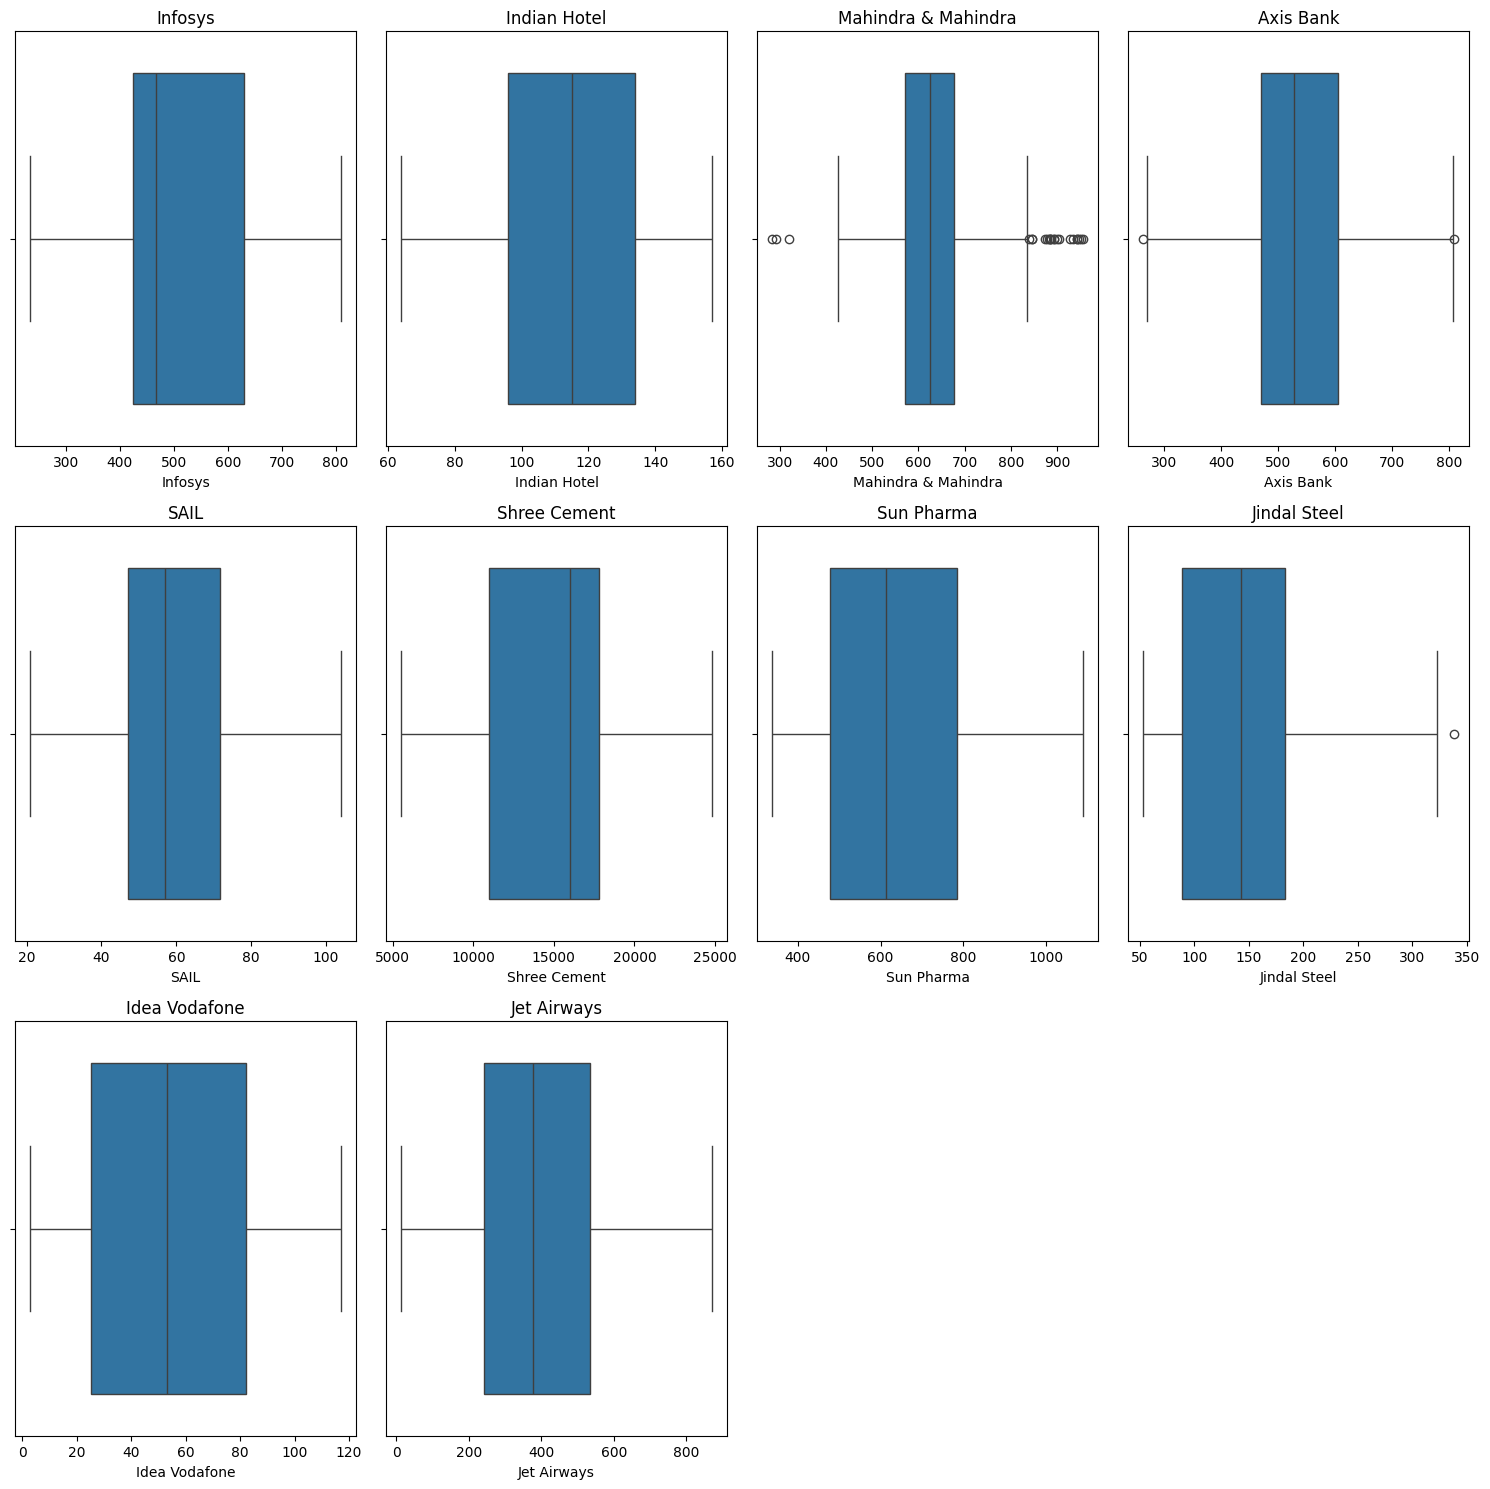

In [11]:
# outlier detection using boxplot
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

# Calculate the number of rows and columns needed for subplots
n_cols = 4
n_rows = (len(numeric_columns) + n_cols - 1) // n_cols

plt.figure(figsize=(15, n_rows * 5))

for i, variable in enumerate(numeric_columns):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(data=df, x=variable, whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

> We see that `Manhidra & Mahindar`, `Axis Bank` `Jindal Steel` have outliers.  We did not treat outliers as we do not know if they are explainable.

In [12]:
# Conveting the Date column to date/time
df['Date'] = pd.to_datetime(df['Date'])

/tmp/ipython-input-1597117234.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


In [13]:
#Setting Date as the index
df.set_index('Date', inplace=True)

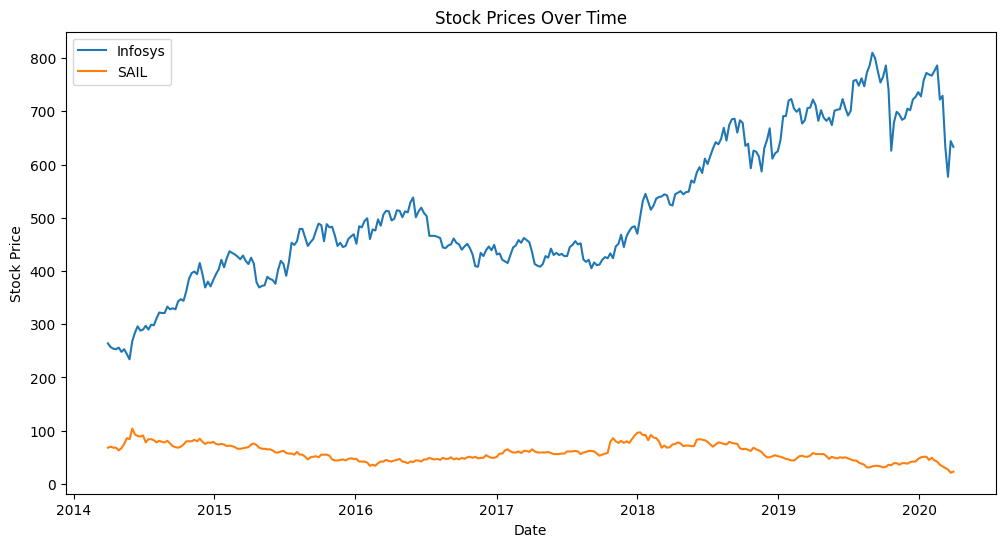

In [14]:
# Plotting InfoSys and Axis Bank vs Date
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Infosys'], label='Infosys')
plt.plot(df.index, df['SAIL'], label='SAIL')


plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.title('Stock Prices Over Time')
plt.legend()
plt.show()


>  1. Although there are smaller fluctions in Infosys there is an upward trend in the stock as opposed to SAIL, where there is less fluctions and a small decline in price over time.
2. The overall price of Infosys is much higher than SAIL
Infosys appears to be a better choice for investement.

In [15]:
# Calcualting the returns by looking at percentage change i.e. (current-pervious/previous)

returns_df = df.pct_change()

In [16]:
returns_df.head()

,Infosys,Indian Hotel,Mahindra & Mahindra,Axis Bank,SAIL,Shree Cement,Sun Pharma,Jindal Steel,Idea Vodafone,Jet Airways
Date,,,,,,,,,,
2014-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-04-07,-0.026515,-0.014493,0.006593,0.049430,0.029412,0.033375,0.099099,-0.063758,0.012048,0.089928
2014-04-14,-0.011673,0.000000,-0.008734,-0.021739,-0.028571,-0.013792,-0.004918,0.000000,-0.011905,-0.075908
2014-04-21,-0.003937,0.000000,0.074890,0.048148,0.000000,0.007612,-0.004942,-0.017921,0.000000,0.007143
2014-04-28,0.011858,-0.044118,-0.012295,-0.003534,-0.073529,-0.019325,0.011589,-0.131387,-0.048193,-0.138298


In [17]:
returns_df.tail()

,Infosys,Indian Hotel,Mahindra & Mahindra,Axis Bank,SAIL,Shree Cement,Sun Pharma,Jindal Steel,Idea Vodafone,Jet Airways
Date,,,,,,,,,,
2020-03-02,0.009695,-0.104478,0.030769,-0.055954,-0.083333,0.023971,0.075067,-0.051948,-0.25,-0.120000
2020-03-09,-0.130316,-0.050000,-0.089552,-0.135258,-0.090909,-0.077975,-0.042394,-0.171233,1.00,-0.181818
2020-03-16,-0.089905,-0.210526,-0.248244,-0.247803,-0.100000,-0.112821,-0.049479,-0.132231,-0.50,-0.111111
2020-03-23,0.116118,-0.166667,-0.087227,-0.158879,-0.222222,-0.065489,-0.073973,-0.152381,0.00,-0.125000
2020-03-30,-0.017081,0.000000,-0.030717,0.052778,0.095238,-0.006793,0.041420,-0.078652,0.00,0.000000


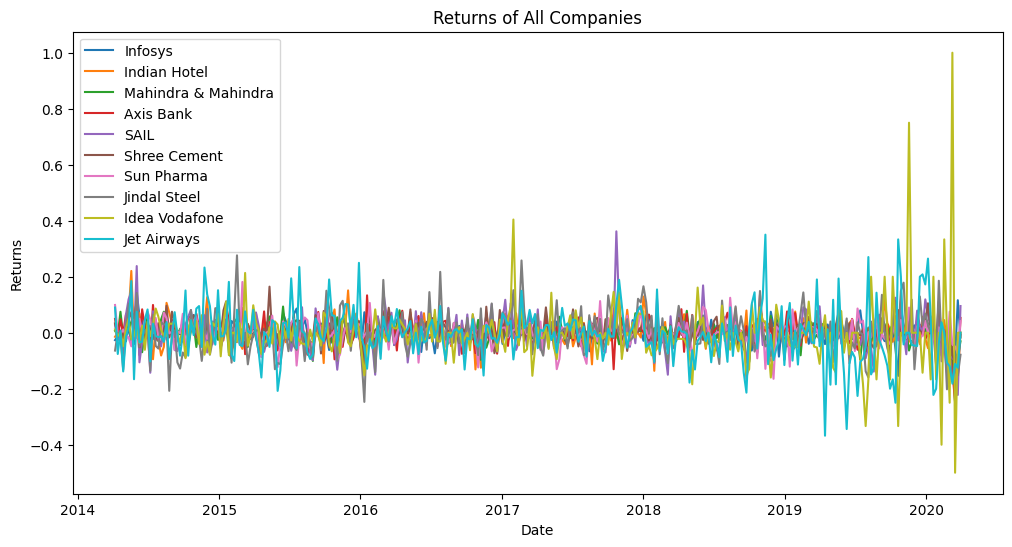

In [18]:
# plotting the returns of all companies
plt.figure(figsize=(12, 6))
for column in returns_df.columns:
    plt.plot(returns_df.index, returns_df[column], label=column)
#Adding legend
plt.legend()
plt.xlabel('Date')
plt.ylabel('Returns')
plt.title('Returns of All Companies')
plt.show()

>  In 2017, 2019 and 2020 we see that Idea Vodafone had a lot more fluctuations in the returns.  
>  In 2019 and 2020 Jet Airways had alot of fluctions as well.

In [19]:
# Calcualting Stock mean
# Mean return of each stock
df_mean = df.mean()
df_mean

,0
Infosys,511.340764
Indian Hotel,114.560510
Mahindra & Mahindra,636.678344
Axis Bank,540.742038
SAIL,59.095541
Shree Cement,14806.410828
Sun Pharma,633.468153
Jindal Steel,147.627389
Idea Vodafone,53.713376
Jet Airways,372.659236


In [20]:
# Calculating Standard deviation
df_std = df.std()
df_std

,0
Infosys,135.952051
Indian Hotel,22.509732
Mahindra & Mahindra,102.879975
Axis Bank,115.835569
SAIL,15.810493
Shree Cement,4288.275085
Sun Pharma,171.855893
Jindal Steel,65.879195
Idea Vodafone,31.248985
Jet Airways,202.262668


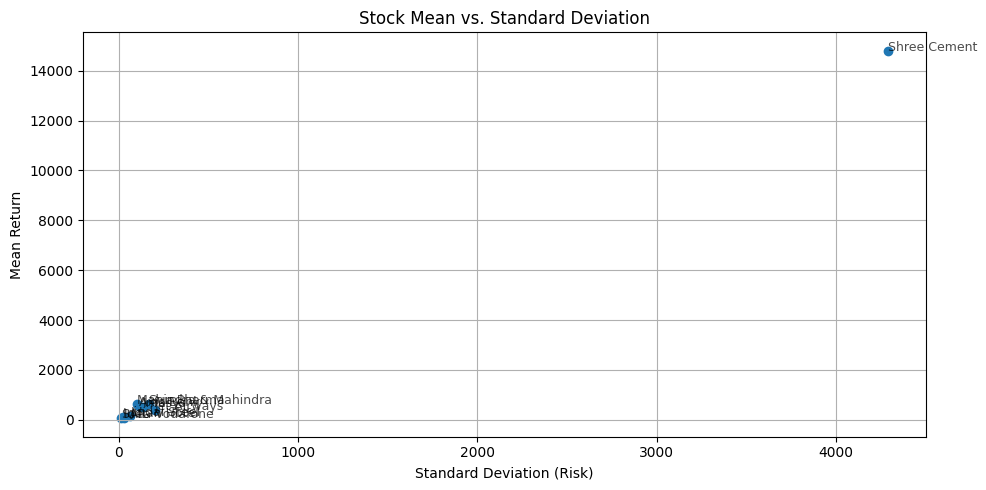

In [21]:
# Create scatter plot
plt.figure(figsize=(10 ,5))
plt.scatter(df_std, df_mean)

# Labelling each point with company name
for stock in df_mean.index:
    plt.annotate(stock, (df_std[stock], df_mean[stock]), fontsize=9, alpha=0.7)

# Labels and title
plt.xlabel('Standard Deviation (Risk)')
plt.ylabel('Mean Return')
plt.title('Stock Mean vs. Standard Deviation')
plt.grid(True)
plt.tight_layout()

plt.show()

>1.  Most of the stocks are clustered on the bottom left.  Their means are small and the standard deviation are small indicating less flucations hence more stable.
2.  `Shree Cement` have a high std dev and mean indicating larger fluctuations hence higher volatility. As the mean is also high, then there are higher returns on average.  

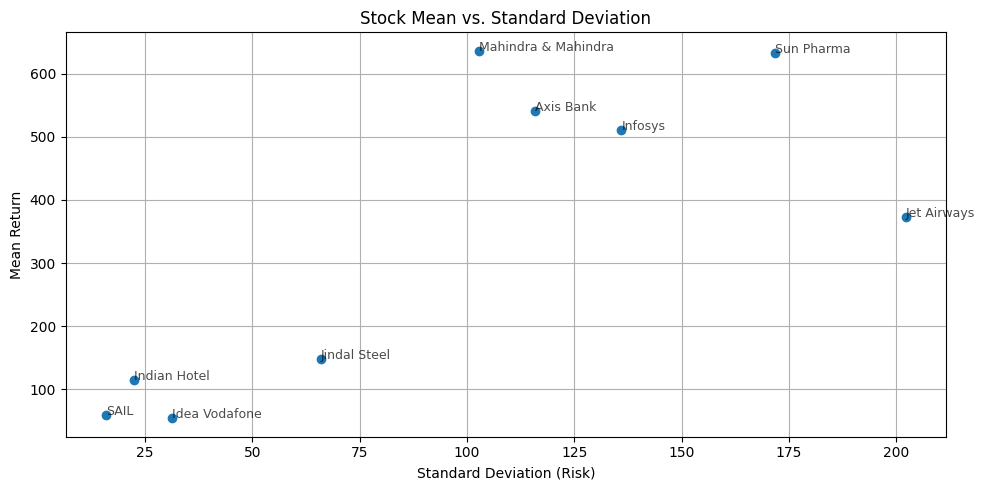

In [22]:
#plotting scatterplot with out Shree Cement
plt.figure(figsize=(10 ,5))
plt.scatter(df_std[df_std.index != 'Shree Cement'], df_mean[df_mean.index != 'Shree Cement'])

# Labelling each point with company name
for stock in df_mean.index:
    plt.annotate(stock, (df_std[stock], df_mean[stock]), fontsize=9, alpha=0.7)

# Labels and title

# Labels and title
plt.xlabel('Standard Deviation (Risk)')
plt.ylabel('Mean Return')
plt.title('Stock Mean vs. Standard Deviation')
plt.grid(True)
plt.tight_layout()

plt.show()

> Removing `Shree Cement` we see:
1.  The stocks with less variation in prices are `Indian Hotel`, `Jindal Steel`, `SAIL` and `Idea Vodafone`.  These stocks are less volatile, but they have on average less returns.
2.  `Mahindra and Mahindra`, `Axis Bank` and `Infosys` shows medium riskk and returns on investments.
3. `Sun Pharma` shows higher volatility where are `Jet Airways` shows higher volatility but with lower returns.

#  Conclusions
>  1.  Shree Cement is out performing the other companies.  This company has a high volatility but also high rewards.
2.  `Indian Hotel`, `Jindal Steel`, `SAIL` and `Idea Vodafone` are more stable in terms of volatility but has low returns.
3.  `Jet Airwary` on average do not have as much returns as `Mahindra and Mahindra`, `Axis Bank` and `Infosys` but has more volatility.
4. `Mahindra and Mahindra`, `Axis Bank` and `Infosys`  have higher returns but with less volatility.

# Recommendations
1.  If you are looking to invest in more stable stocks even if the retruns are lower, then invest in `Indian Hotel`, `Jindal Steel`, `SAIL` and `Idea Vodafone`.
2.  If you are looking for high returns and willing to be exposed to higher risk then invest in `Shree Cement`.
3.  I would advise to avoid trading in `Jet Airways` as the volatility is high abd there are other stocks which are giving higher returns with a lower volatility.
4.  For any furhter analysis or modeling, We should either scale the dataset or remove Shree Cement to a higher performing data so that we can properly analyse the remaining.


